## Dataset
NASA Bearing Dataset available at: https://www.kaggle.com/datasets/vinayak123tyagi/bearing-dataset

### About (Set No.2 Feb 2004 - Feb 2004)
<strong> Physical configuration </strong>
- 4 Bearings in a shaft rotating at constant 2000 RPM on AC motor.
- Radial load of 6000lbs / 2721kg
- Ran till failure (test-to-failure), at the end: <strong>outer race failure occurred in
bearing 1</strong>
<strong>Data Acquisition</strong>
- Duration is 6days, 19hrs, 50mins & 0secs (February 12, 2004 10:32:39 to February 19, 2004 06:22:39)
- Readings collected at 1sec intervals
- Every 10 minutes
- Sample rate is 20kHz (20.48kHz) with 20480 rows per file

### Note
There are also two more sets.

## Includes

In [35]:
import os
import pandas as pd

DEBUG = True

## Read data

In [36]:
DATASET_LOC = "./Datasets/"
NASA_BEARING_DATASET_LOC = DATASET_LOC + "NASABearing/"


# For all sets_directories (not files) in dataset dir - Path.join is concatenates full path str lit to directory
sets_directories = [os.path.join(NASA_BEARING_DATASET_LOC, d)+f"/{d}/" for d in  os.listdir(NASA_BEARING_DATASET_LOC) if os.path.isdir(os.path.join(NASA_BEARING_DATASET_LOC, d))]
if DEBUG:
    for dir in sets_directories:
        print(dir)
    # Using set/run 2
    print(f"Using set: {sets_directories[1]}")


print(f"Count of bursts/files: {len(os.listdir(sets_directories[1]))}")



./Datasets/NASABearing/1st_test/1st_test/
./Datasets/NASABearing/2nd_test/2nd_test/
./Datasets/NASABearing/3rd_test/3rd_test/
Using set: ./Datasets/NASABearing/2nd_test/2nd_test/
Count of bursts/files: 984


### Note 
How the data is aquired in this dataset is:
- each file is a roughly a second (1.024s percisly) of data collection. 
- in that burst (second time period) 20480 datapoints are collected.

Might be worth looking into FFT & keeping at powers of 2 for standardisation? 

## Creating Feature Table

In [37]:
import numpy as np
import scipy.stats as stats

DATAPOINTS_PER_FILE = 20480
SAMPLE_RATE = 20000 # 20 kHz


time_step = 1 / SAMPLE_RATE
# np.arange returns arr of evenly spaced values within the given interval 
# so a float timestamp that can be used in timedelta at the 
# files starting point (such 2004.02.19.06.22.39) - there are 20480 
# datapoints which need time indexing/stamping
# Kind reminds me of pandas resample method but for relative (not actual) time in a given time period
timestamps = np.arange(DATAPOINTS_PER_FILE) * time_step
#print(timestamps)

features = [
    "rms",
    "std",
    "ptp",
    "kurtosis",
    "skew",
    "crest"
]

df = pd.DataFrame(columns=features) #columns=["b1", "b2", "b3", "b4"])


## ---- Time Domain Features
# Feature	Meaning
# RMS	Overall vibration energy
# Std	Signal spread
# Mean	Should be ~0 (after de-meaning)
# Peak-to-peak	Max impulse size
# Kurtosis	Impulsiveness (very important)
# Skewness	Asymmetry
# Crest factor	Peak / RMS
## ---- Calcuation
# Where x the 20480 readings in a burst for the deterioted bearing (b1)
# features = {
#     "rms": np.sqrt(np.mean(x**2)),
#     "std": np.std(x),
#     "ptp": np.ptp(x),
#     "kurtosis": stats.kurtosis(x, fisher=False),
#     "skew": stats.skew(x),
#     "crest": np.max(np.abs(x)) / np.sqrt(np.mean(x**2))
# }


for file_reading_interval in os.listdir(sets_directories[1]):
    # print(file_reading_interval)
    time_interval_df = pd.read_csv(
        sets_directories[1]+file_reading_interval, 
        delimiter="\t", 
        names=["b1", "b2", "b3", "b4"], header=None)
    
    start = pd.to_datetime(file_reading_interval, format="%Y.%m.%d.%H.%M.%S")
    time_interval_df.index = start + pd.to_timedelta(timestamps, unit="s")

    # print(f"reading starts at: {time_interval_df.index[0]}")
    # print(f"reading ends at: {time_interval_df.index[-1]}")
    # print(time_interval_df)
    # break

    b1_readings = time_interval_df["b1"]
    
    # TIME DOMAIN NOT FREQUENCY
    features_dict = {}
    
    features_dict["id"] = file_reading_interval


    features_dict["rms"] = np.sqrt(np.mean(b1_readings**2))
    features_dict["std"] = np.std(b1_readings)
    features_dict["ptp"] = np.ptp(b1_readings)
    features_dict["kurtosis"] = stats.kurtosis(b1_readings, fisher=False)
    features_dict["skew"] = stats.skew(b1_readings)
    features_dict["crest"] = np.max(np.abs(b1_readings)) / np.sqrt(np.mean(b1_readings**2))
    
    df.loc[len(df)] = features_dict

df.index = os.listdir(sets_directories[1])

print(df)

                          rms       std    ptp   kurtosis      skew     crest
2004.02.12.10.32.39  0.074179  0.073475  0.840   3.628763  0.083993  6.120331
2004.02.12.10.42.39  0.075382  0.075338  0.757   3.648291  0.052142  5.147086
2004.02.12.10.52.39  0.076230  0.076189  0.903   3.513475  0.032808  6.598472
2004.02.12.11.02.39  0.078724  0.078691  1.184   4.157953  0.041486  7.723217
2004.02.12.11.12.39  0.078474  0.078437  0.782   3.603177  0.028224  4.982524
...                       ...       ...    ...        ...       ...       ...
2004.02.19.05.42.39  0.725001  0.724996  9.998  15.577705 -0.510556  6.896538
2004.02.19.05.52.39  0.462012  0.461990  5.569   6.759972 -0.325368  6.235773
2004.02.19.06.02.39  0.483835  0.483832  7.197   7.891755 -0.377095  7.638962
2004.02.19.06.12.39  0.002103  0.000987  0.005   6.637513  0.579698  2.377543
2004.02.19.06.22.39  0.001533  0.001000  0.007   1.390226  0.317032  3.262149

[984 rows x 6 columns]


## Visualise

<Axes: title={'center': 'B1 features of Run-Till-Failure'}, xlabel='time (10min intervals)', ylabel='somethign'>

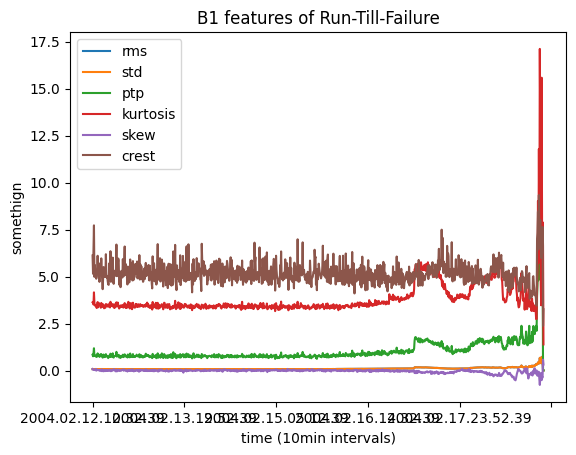

In [38]:
df.plot(xlabel="time (10min intervals)", ylabel="somethign", title="B1 features of Run-Till-Failure")

## Defining RUL

In [39]:
N = len(df)

# Remaining bursts × hours per burst = remaining hours
HOURS_PER_BURST = 10 / 60
print(f"bursts per hour (Factored in with numpy arange): {HOURS_PER_BURST}")

# (len(df)-1) reverses the order of np.arange from highest to lowest
print(f"np.arange() does: {np.arange(10)}...n")
df["RUL_Time"] = ((len(df) - 1) - np.arange(len(df))) * HOURS_PER_BURST

CLIPPING = True
if CLIPPING:
    df["RUL_Time"] = df["RUL_Time"].clip(upper=40) 

df

bursts per hour (Factored in with numpy arange): 0.16666666666666666
np.arange() does: [0 1 2 3 4 5 6 7 8 9]...n


,rms,std,ptp,kurtosis,skew,crest,RUL_Time
2004.02.12.10.32.39,0.074179,0.073475,0.840,3.628763,0.083993,6.120331,40.000000
2004.02.12.10.42.39,0.075382,0.075338,0.757,3.648291,0.052142,5.147086,40.000000
2004.02.12.10.52.39,0.076230,0.076189,0.903,3.513475,0.032808,6.598472,40.000000
2004.02.12.11.02.39,0.078724,0.078691,1.184,4.157953,0.041486,7.723217,40.000000
2004.02.12.11.12.39,0.078474,0.078437,0.782,3.603177,0.028224,4.982524,40.000000
...,...,...,...,...,...,...,...
2004.02.19.05.42.39,0.725001,0.724996,9.998,15.577705,-0.510556,6.896538,0.666667
2004.02.19.05.52.39,0.462012,0.461990,5.569,6.759972,-0.325368,6.235773,0.500000
2004.02.19.06.02.39,0.483835,0.483832,7.197,7.891755,-0.377095,7.638962,0.333333
2004.02.19.06.12.39,0.002103,0.000987,0.005,6.637513,0.579698,2.377543,0.166667


## Normalise Features

In [40]:
from sklearn.preprocessing import StandardScaler


features_extracted = df[features]
# print(features_extracted)

healthy = features_extracted.iloc[:50] # Using datapoints from early & healthy time-period
print(f"Note - must fit scaler on only the health data (first 50) - last:\n {healthy.iloc[len(healthy)-1]}")
scaler = StandardScaler()
scaler.fit(healthy)

features_scaled = scaler.transform(features_extracted)
# print(features_scaled)


norm_features = pd.DataFrame(features_scaled, columns=features)

df[norm_features.columns] = norm_features.values
df


Note - must fit scaler on only the health data (first 50) - last:
 rms         0.076970
std         0.076940
ptp         0.771000
kurtosis    3.424313
skew        0.046608
crest       5.261802
Name: 2004.02.12.18.42.39, dtype: float64


,rms,std,ptp,kurtosis,skew,crest,RUL_Time
2004.02.12.10.32.39,-3.387789,-3.788649,0.641640,1.105170,2.200700,1.353260,40.000000
2004.02.12.10.42.39,-2.361957,-2.266910,-0.363572,1.253837,1.147784,-0.273292,40.000000
2004.02.12.10.52.39,-1.639701,-1.571725,1.404633,0.227503,0.508663,2.152361,40.000000
2004.02.12.11.02.39,0.486110,0.471312,4.807822,5.133820,0.795531,4.032110,40.000000
2004.02.12.11.12.39,0.273532,0.264443,-0.060797,0.910389,0.357128,-0.548320,40.000000
...,...,...,...,...,...,...,...
2004.02.19.05.42.39,551.375499,528.333881,111.554125,92.070804,-17.453332,2.650509,0.666667
2004.02.19.05.52.39,327.202096,313.526462,57.914532,24.942629,-11.331555,1.546195,0.500000
2004.02.19.06.02.39,345.804717,331.366086,77.631230,33.558740,-13.041511,3.891298,0.333333
2004.02.19.06.12.39,-64.825606,-62.992064,-9.471040,24.010365,18.587212,-4.901939,0.166667


<Axes: >

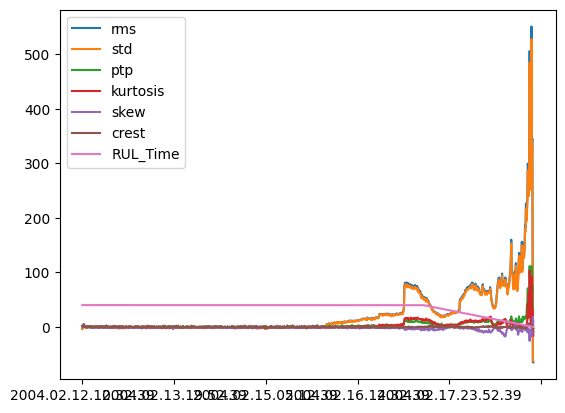

In [41]:
df.plot()

In [42]:
# Structure into windows of 30 bursts (1 burst is 10 mins, 6 bursts per hour, 30/6 = 5hour windows)
WIN_SEQUENCY_LEN = 30
x,y = [],[]
df
for i in range(len(df) - WIN_SEQUENCY_LEN):
    x.append(df[features].iloc[i:i+WIN_SEQUENCY_LEN].values)
    y.append(df["RUL_Time"].iloc[i+WIN_SEQUENCY_LEN])
        

x = np.array(x)
y = np.array(y)


# Clarity Check
features_count = len(features)
samples_count = len(df) - WIN_SEQUENCY_LEN
features_count

print(f"features: {features} ({features_count})")
print(f"Samples are dataset rows count - Sequency len: {samples_count}")

# Dimension	    Meaning
# 954	        Number of training samples
# 30	        Bursts per sample (timesteps)
# 6	            Features per burst
print(f"x shape: {x.shape}")
print(f"y shape: {y.shape}")


features: ['rms', 'std', 'ptp', 'kurtosis', 'skew', 'crest'] (6)
Samples are dataset rows count - Sequency len: 954
x shape: (954, 30, 6)
y shape: (954,)


## Note for above cell 
LSTM is predicting one RUL value per sequence, using the sequence as context.
1 sequence consists of bursts
1 burst consist of 6 features: 'rms', 'std', 'ptp', 'kurtosis', 'skew' & 'crest' 
<br>
(With current setup (11/01/2026 23:59))

In [43]:
print("len: ", len(x)) # x & y should have same length yo
print(f"Bursts per sequence: {len(x[0])}")
print(f"Features per burst: {len(x[0][0])}")
print(f"\nx = {x[953]}") # - x = list of sequencies which contains features for bursts in that sequence window
print(f"\ny (RUL) = {y[953]}")



len:  954
Bursts per sequence: 30
Features per burst: 6

x = [[ 1.02805343e+02  9.85310762e+01  8.05356891e+00 -6.89607077e-01
  -6.88766683e+00 -2.49341591e+00]
 [ 1.34671265e+02  1.29060780e+02  1.22560839e+01  9.81175681e-01
  -6.96233369e+00 -1.98212080e+00]
 [ 1.06409778e+02  1.01982598e+02  9.68855312e+00  5.90352979e-01
  -7.85285130e+00 -1.77833189e+00]
 [ 1.21798649e+02  1.16730866e+02  1.24377488e+01 -1.37216095e-01
  -4.30493263e+00 -1.89677348e+00]
 [ 1.10017807e+02  1.05433789e+02  8.50167569e+00 -2.39688346e+00
  -5.89785054e+00 -2.35881753e+00]
 [ 1.56311870e+02  1.49794284e+02  1.53928314e+01  2.56035642e+00
  -3.96789892e+00 -2.07615181e+00]
 [ 1.05245601e+02  1.00872278e+02  9.09511440e+00  1.32012981e-01
  -9.33058179e+00 -2.19444602e+00]
 [ 1.23382018e+02  1.18246575e+02  1.41211770e+01  6.65019981e-01
  -1.94515829e+00 -5.30338167e-01]
 [ 1.54360925e+02  1.47923102e+02  1.91472396e+01 -2.40041006e+00
  -3.41723370e+00 -4.88247108e-01]
 [ 1.30854364e+02  1.25404944e

## Last check of RUL degradation

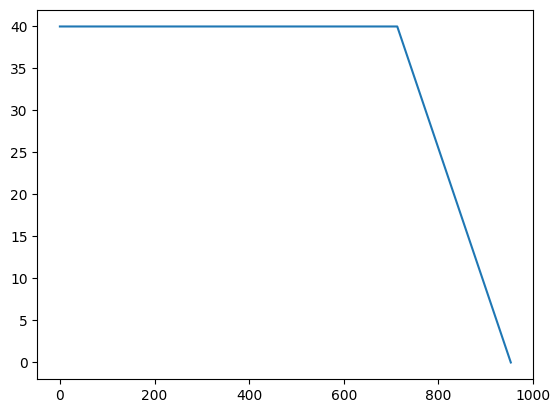

In [44]:
import matplotlib.pyplot as plt

plt.plot(y) 

## Split train & test data
for this example first 70% on train, last 30% on testing 

In [58]:
split_pivot = int(.7 * len(x))

x_train = x[:split_pivot]
y_train = y[:split_pivot]

x_test = x[split_pivot:]
y_test = y[split_pivot:]

print(len(x_train))
print(len(x_test))
print(len(x_train)+len(x_test))


667
287
954


## Construct Model

In [59]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam

model = Sequential([
    LSTM(64, input_shape=(WIN_SEQUENCY_LEN, features_count), return_sequences=False),
    Dense(32, activation="relu"),
    #Dropout(.2), # For preventing overfitting (model gets too used to training data)
    Dense(1)
])

model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss="mse",
    metrics=["mae"] # Mean Absolute Error
)

model.summary()

# Learn training data
history = model.fit(
    x_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_data=(x_test, y_test), # 
    shuffle=False # Dont shuffle time-series
)

Model: "sequential_6"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_6 (LSTM)               (None, 64)                18176     
                                                                 
 dense_12 (Dense)            (None, 32)                2080      
                                                                 
 dense_13 (Dense)            (None, 1)                 33        
                                                                 
Total params: 20289 (79.25 KB)
Trainable params: 20289 (79.25 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________
Epoch 1/50
21/21 [==============================] - 2s 26ms/step - loss: 1571.3838 - mae: 39.6381 - val_loss: 698.7454 - val_mae: 23.0725
Epoch 2/50
21/21 [==============================] - 0s 11ms/step - loss: 1333.8699 - mae: 36.4632 - val_loss: 665.1830 - val_mae: 22.3607
Epoch 

9/9 [==============================] - 0s 4ms/step - loss: 136.1103 - mae: 9.7096
Mean Average Error (MAE):  9.709569931030273
9/9 [==============================] - 0s 3ms/step


<function matplotlib.pyplot.show(close=None, block=None)>

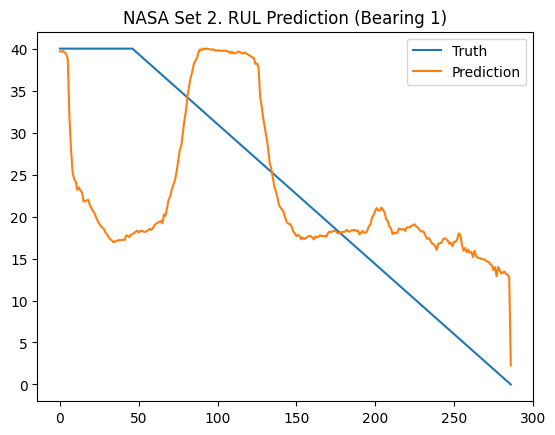

In [60]:
test_loss, test_mae = model.evaluate(x_test, y_test)
print("Mean Average Error (MAE): ", test_mae)

rul_prediction = model.predict(x_test).flatten()

plt.plot(y_test, label="Truth")
plt.plot(rul_prediction, label="Prediction")
plt.legend()
plt.title("NASA Set 2. RUL Prediction (Bearing 1)")
plt.show

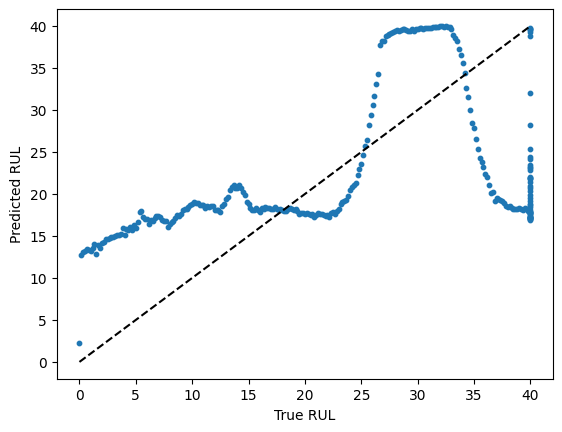

In [61]:
plt.scatter(y_test, rul_prediction, s=10)
plt.xlabel("True RUL")
plt.ylabel("Predicted RUL")
plt.plot([0, max(y_test)], [0, max(y_test)], "k--")
plt.show()

In [63]:
rul_prediction = model.predict(x_test).squeeze()

late_mask = y_test < 20  # same length as y_test

late_mae = np.mean(np.abs(rul_prediction[late_mask] - y_test[late_mask]))
print("Late-life MAE:", late_mae)

9/9 [==============================] - 0s 3ms/step
Late-life MAE: 7.445396856466929
